Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DAY 1: TOPIC CLASSIFICATION

Loading dataset...
Dataset: 2225 articles, 2 columns
Categories: ['tech', 'business', 'sport', 'entertainment', 'politics']
Distribution:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

Preprocessing text...
Training: 1780 samples
Test: 445 samples

Creating TF-IDF features...
TF-IDF shape: (1780, 10000)

Training models...

1/7: SVM
   Accuracy: 0.9820
2/7: Random Forest
   Accuracy: 0.9640
3/7: XGBoost
   Accuracy: 0.9663
4/7: Feedforward Neural Network
   Accuracy: 0.9843
5/7: Logistic Regression
   Accuracy: 0.9843
6/7: Naive Bayes
   Accuracy: 0.9865
7/7: Ensemble
   Accuracy: 0.9820

All models trained successfully!

RESULTS
              Model  Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
        Naive Bayes  0.9865

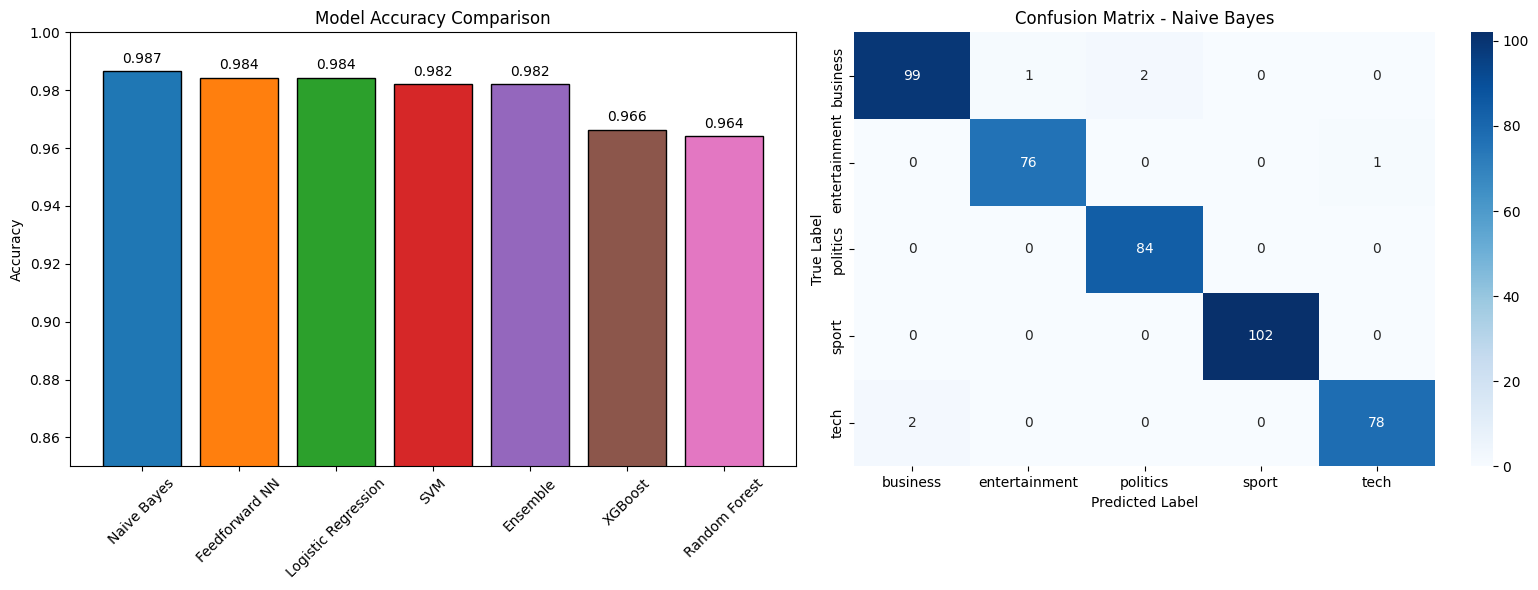


SAVING RESULTS
Results saved to: /content/drive/MyDrive/day1_results.csv
Predictions saved to: /content/drive/MyDrive/day1_predictions.csv

DONE!

Best Model: Naive Bayes
Best Accuracy: 0.9865
Best F1-Score: 0.9863

Files saved to Google Drive:
  - day1_results.csv
  - day1_predictions.csv


In [11]:
# ============================================================================
# DAY 1: TOPIC CLASSIFICATION - BBC NEWS
# Models: SVM, Random Forest, XGBoost, FNN, Logistic Regression, Naive Bayes, Ensemble
# ============================================================================

!pip install xgboost scikit-learn pandas matplotlib seaborn nltk -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import warnings
warnings.filterwarnings('ignore')

import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

from google.colab import drive
drive.mount('/content/drive')

print("="*70)
print("DAY 1: TOPIC CLASSIFICATION")
print("="*70)

# Load dataset
print("\nLoading dataset...")
file_path = '/content/bbc-text.csv'

try:
    df = pd.read_csv(file_path)
except:
    df = pd.read_csv('/content/drive/MyDrive/bbc-text.csv')

print(f"Dataset: {df.shape[0]} articles, {df.shape[1]} columns")
print(f"Categories: {df['category'].unique().tolist()}")
print(f"Distribution:\n{df['category'].value_counts()}")

# Clean text
print("\nPreprocessing text...")
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['category'])

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
)

print(f"Training: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")

# TF-IDF features
print("\nCreating TF-IDF features...")
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(f"TF-IDF shape: {X_train_tfidf.shape}")

# Train all models
print("\nTraining models...\n")
print("="*70)

models = {}
predictions = {}
metrics = {}

# SVM
print("1/7: SVM")
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)
models['SVM'] = svm
predictions['SVM'] = y_pred_svm
metrics['SVM'] = {
    'Accuracy': accuracy_score(y_test, y_pred_svm),
    'F1-Macro': f1_score(y_test, y_pred_svm, average='macro')
}
print(f"   Accuracy: {metrics['SVM']['Accuracy']:.4f}")

# Random Forest
print("2/7: Random Forest")
rf = RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)
models['Random Forest'] = rf
predictions['Random Forest'] = y_pred_rf
metrics['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'F1-Macro': f1_score(y_test, y_pred_rf, average='macro')
}
print(f"   Accuracy: {metrics['Random Forest']['Accuracy']:.4f}")

# XGBoost
print("3/7: XGBoost")
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train_tfidf, y_train)
y_pred_xgb = xgb.predict(X_test_tfidf)
models['XGBoost'] = xgb
predictions['XGBoost'] = y_pred_xgb
metrics['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'F1-Macro': f1_score(y_test, y_pred_xgb, average='macro')
}
print(f"   Accuracy: {metrics['XGBoost']['Accuracy']:.4f}")

# Feedforward Neural Network
print("4/7: Feedforward Neural Network")
fnn = MLPClassifier(hidden_layer_sizes=(512, 256, 128), activation='relu',
                    solver='adam', max_iter=200, random_state=42, early_stopping=True)
fnn.fit(X_train_tfidf.toarray(), y_train)
y_pred_fnn = fnn.predict(X_test_tfidf.toarray())
models['Feedforward NN'] = fnn
predictions['Feedforward NN'] = y_pred_fnn
metrics['Feedforward NN'] = {
    'Accuracy': accuracy_score(y_test, y_pred_fnn),
    'F1-Macro': f1_score(y_test, y_pred_fnn, average='macro')
}
print(f"   Accuracy: {metrics['Feedforward NN']['Accuracy']:.4f}")

# Logistic Regression
print("5/7: Logistic Regression")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
models['Logistic Regression'] = lr
predictions['Logistic Regression'] = y_pred_lr
metrics['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'F1-Macro': f1_score(y_test, y_pred_lr, average='macro')
}
print(f"   Accuracy: {metrics['Logistic Regression']['Accuracy']:.4f}")

# Naive Bayes
print("6/7: Naive Bayes")
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)
models['Naive Bayes'] = nb
predictions['Naive Bayes'] = y_pred_nb
metrics['Naive Bayes'] = {
    'Accuracy': accuracy_score(y_test, y_pred_nb),
    'F1-Macro': f1_score(y_test, y_pred_nb, average='macro')
}
print(f"   Accuracy: {metrics['Naive Bayes']['Accuracy']:.4f}")

# Ensemble
print("7/7: Ensemble")
voting = VotingClassifier(
    estimators=[
        ('svm', SVC(kernel='rbf', C=1.0, probability=True, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42)),
        ('xgb', XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='mlogloss')),
        ('lr', LogisticRegression(max_iter=1000, random_state=42))
    ],
    voting='soft'
)
voting.fit(X_train_tfidf, y_train)
y_pred_voting = voting.predict(X_test_tfidf)
models['Ensemble'] = voting
predictions['Ensemble'] = y_pred_voting
metrics['Ensemble'] = {
    'Accuracy': accuracy_score(y_test, y_pred_voting),
    'F1-Macro': f1_score(y_test, y_pred_voting, average='macro')
}
print(f"   Accuracy: {metrics['Ensemble']['Accuracy']:.4f}")

print("\n" + "="*70)
print("All models trained successfully!")
print("="*70)

# Results table
print("\n" + "="*70)
print("RESULTS")
print("="*70)

results_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': m['Accuracy'],
        'Precision (macro)': precision_score(y_test, predictions[name], average='macro'),
        'Recall (macro)': recall_score(y_test, predictions[name], average='macro'),
        'F1-Score (macro)': m['F1-Macro']
    }
    for name, m in metrics.items()
])

results_df = results_df.sort_values('Accuracy', ascending=False)
print(results_df.to_string(index=False))

# Best model details
print("\n" + "="*70)
print("BEST MODEL DETAILS")
print("="*70)

best_model = results_df.iloc[0]['Model']
print(f"\nBest Model: {best_model}")
print(f"Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"F1-Score: {results_df.iloc[0]['F1-Score (macro)']:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, predictions[best_model], target_names=label_encoder.classes_))

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
ax1 = axes[0]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
bars = ax1.bar(results_df['Model'], results_df['Accuracy'], color=colors, edgecolor='black')
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylim(0.85, 1.0)
ax1.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, results_df['Accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)

# Confusion matrix
ax2 = axes[1]
cm = confusion_matrix(y_test, predictions[best_model])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=ax2)
ax2.set_title(f'Confusion Matrix - {best_model}')
ax2.set_ylabel('True Label')
ax2.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Save results
print("\n" + "="*70)
print("SAVING RESULTS")
print("="*70)

results_df.to_csv('/content/drive/MyDrive/day1_results.csv', index=False)
print("Results saved to: /content/drive/MyDrive/day1_results.csv")

predictions_df = pd.DataFrame({
    'text': X_test,
    'true_category': label_encoder.inverse_transform(y_test),
    **{f'{name}_pred': label_encoder.inverse_transform(preds)
       for name, preds in predictions.items()}
})
predictions_df.to_csv('/content/drive/MyDrive/day1_predictions.csv', index=False)
print("Predictions saved to: /content/drive/MyDrive/day1_predictions.csv")

print("\n" + "="*70)
print("DONE!")
print("="*70)
print(f"\nBest Model: {best_model}")
print(f"Best Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"Best F1-Score: {results_df.iloc[0]['F1-Score (macro)']:.4f}")
print("\nFiles saved to Google Drive:")
print("  - day1_results.csv")
print("  - day1_predictions.csv")

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
